<a href="https://colab.research.google.com/github/Sandrajol/NLP_Tarea_04/blob/main/mini_proyecto_generacion_texto_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 04 - Procesamiento de Lenguaje Natural

## Generación de texto a partir de reseñas de productos en español

### Objetivo

Analizar cómo diferentes estrategias de decodificación afectan la generación
de texto utilizando como corpus reseñas de productos en español.

Se utilizará el dataset **Amazon Reviews Multi** y se compararán diferentes
métodos de generación para estudiar su efecto sobre la diversidad,
repetición y coherencia del texto generado.

## 1. Planteamiento del problema

Los modelos generativos de lenguaje producen una distribución de probabilidad
sobre los posibles tokens que pueden aparecer a continuación de una secuencia.

Sin embargo, la manera en que se selecciona el siguiente token puede modificar
considerablemente el resultado generado.

Una estrategia determinista como **Greedy Decoding** selecciona siempre el
token con mayor probabilidad, mientras que las estrategias basadas en
muestreo permiten introducir diferentes niveles de variabilidad.

En este trabajo se estudiará cómo estas estrategias afectan la generación
de reseñas de productos en español.

### Pregunta de investigación

**¿Cómo afectan diferentes estrategias de decodificación y valores de
temperatura a la diversidad, repetición y coherencia de las reseñas generadas?**

## 2. Preparación del entorno

In [ ]:
!pip install -q transformers datasets huggingface_hub accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.9 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from datasets import load_dataset
from huggingface_hub import hf_hub_download

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo: cuda
GPU: Tesla T4


## 3. Carga del dataset

Se utilizará el dataset **Amazon Reviews Multi** en español,
el mismo corpus empleado en la Tarea anterior.

El dataset contiene reseñas de productos junto con su calificación.
Para esta actividad se utilizará principalmente el texto de las reseñas
como corpus para la generación de lenguaje.

In [ ]:
repo_id = "mteb/amazon_reviews_multi"

def download_split(split):
    return hf_hub_download(
        repo_id=repo_id,
        repo_type="dataset",
        filename=f"es/{split}.jsonl"
    )

data_files = {
    split: download_split(split)
    for split in ["train", "validation", "test"]
}

raw = load_dataset("json", data_files=data_files)


In [ ]:
print(raw)

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


In [ ]:
print(raw["train"].column_names)

['id', 'text', 'label', 'label_text']


In [ ]:
raw["train"][0]

{'id': 'es_0491108',
 'text': 'television Nevir\n\nNada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante',
 'label': 0,
 'label_text': '0'}

## 4. Análisis exploratorio de datos (EDA)

Antes de utilizar las reseñas para generación de texto, se realiza una exploración
básica del dataset con el fin de conocer su tamaño, distribución de clases y
características generales del texto.

In [ ]:
# Convertimos el conjunto de entrenamiento a DataFrame
df_train = raw["train"].to_pandas()

df_train.head()

,id,text,label,label_text
0,es_0491108,television Nevir\n\nNada bueno se me fue ka pa...,0,0
1,es_0869872,Dinero tirado a la basura con esta compra\n\nH...,0,0
2,es_0811721,solo llega una unidad cuando te obligan a comp...,0,0
3,es_0359921,PRODUCTO NO RECIBIDO.\n\nNo entro en descalifi...,0,0
4,es_0068940,Devuelto\n\nLlega tarde y co la talla equivocada,0,0


In [ ]:
print("Número de registros:", len(df_train))
print("\nValores nulos:")
print(df_train.isnull().sum())

Número de registros: 200000

Valores nulos:
id            0
text          0
label         0
label_text    0
dtype: int64


In [ ]:
print("Distribución de etiquetas:")
print(df_train["label"].value_counts().sort_index())

Distribución de etiquetas:
label
0    40000
1    40000
2    40000
3    40000
4    40000
Name: count, dtype: int64


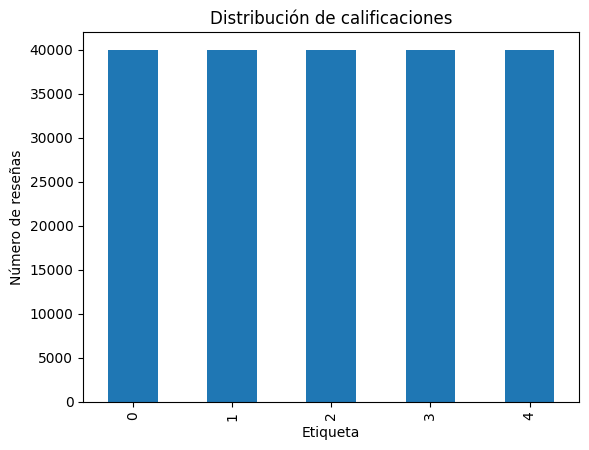

In [ ]:
df_train["label"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de calificaciones")
plt.xlabel("Etiqueta")
plt.ylabel("Número de reseñas")
plt.show()

In [ ]:
df_train["longitud_palabras"] = df_train["text"].apply(
    lambda x: len(str(x).split())
)

df_train["longitud_palabras"].describe()

,longitud_palabras
count,200000.000000
mean,31.120780
std,24.817574
min,3.000000
25%,15.000000
50%,25.000000
75%,38.000000
max,566.000000


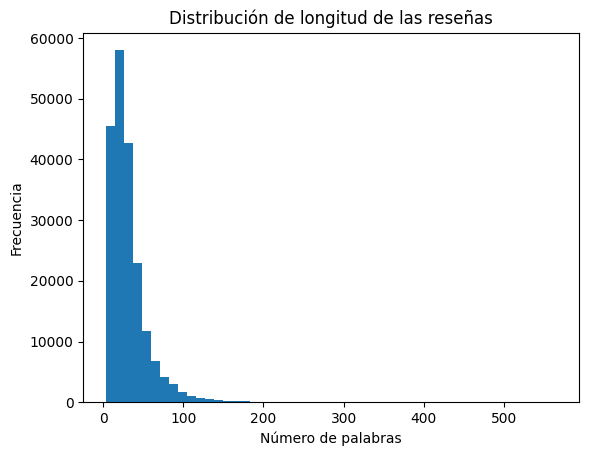

In [ ]:
plt.hist(df_train["longitud_palabras"], bins=50)

plt.title("Distribución de longitud de las reseñas")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación del EDA

El conjunto de entrenamiento contiene 200.000 reseñas y presenta una
distribución aproximadamente balanceada entre las cinco categorías de
calificación. Cada etiqueta contiene alrededor de 40.000 ejemplos, por lo
que no se observa un problema relevante de desbalance de clases.

En relación con la longitud de las reseñas, se observa que la mayoría de
los textos son relativamente cortos. La longitud media es de aproximadamente
31 palabras y la mediana es de 25 palabras.

El 75 % de las reseñas contiene 38 palabras o menos, aunque existen algunos
casos considerablemente más extensos, alcanzando un máximo de 566 palabras.

La distribución presenta una asimetría positiva, con una concentración
importante de reseñas cortas y una cola hacia textos de mayor longitud.

Este comportamiento será tenido en cuenta durante la preparación del corpus,
ya que permitirá definir una longitud máxima adecuada para el entrenamiento
del modelo sin dedicar recursos excesivos a unos pocos textos atípicamente
largos.

In [ ]:
for etiqueta in sorted(df_train["label"].unique()):
    ejemplo = df_train[df_train["label"] == etiqueta].iloc[0]

    print("=" * 80)
    print(f"Etiqueta: {etiqueta}")
    print(ejemplo["text"])
    print()

Etiqueta: 0
television Nevir

Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante

Etiqueta: 1
Regular

Los tornillos no ajustan bien, se caen. No lo volvería a comprar

Etiqueta: 2
buena funda para movil 5,5

cabe bien un móvil de 5,5 y cumple su función se hecha de menos un pequeño espacio para guardar tarjeta o efectivo seria muy útil

Etiqueta: 3
Calidad

Tiene buena pinta, veremos el resultado

Etiqueta: 4
Muy útil

Es muy práctico para cuando me voy de vacaciones, ya no me tengo que preocupar de si seguirán vivas las plantas cuando vuelva. El montaje es muy sencillo y se puede regular la salida de agua para que caiga una gota cada cierto tiempo. Lo recomiendo.



### Exploración cualitativa

Además del análisis estadístico, se revisan ejemplos de cada categoría de
calificación para identificar diferencias en el vocabulario, tono y contenido
de las reseñas.

Esta revisión será útil posteriormente para evaluar de forma cualitativa
si los textos generados mantienen características similares a las reseñas
reales del corpus.

### Interpretación cualitativa

La revisión de ejemplos confirma que las etiquetas representan distintos
niveles de valoración.

Las etiquetas más bajas contienen expresiones claramente negativas,
relacionadas con fallos, inconformidad o rechazo del producto. Las etiquetas
intermedias presentan opiniones más equilibradas, mientras que las etiquetas
más altas utilizan un lenguaje predominantemente positivo.

Esta relación entre la calificación y el contenido de la reseña permite
plantear una estrategia de generación condicionada, incorporando la
calificación como parte del contexto de entrada al modelo.

## 5. Preparación del corpus

Para el entrenamiento del modelo generativo se construirá una representación
textual que combine la calificación de la reseña con su contenido.

De esta manera, el modelo podrá aprender no solamente a generar texto con
la estructura de una reseña, sino también a relacionar diferentes estilos
de lenguaje con distintos niveles de calificación.

In [ ]:
def construir_texto_generativo(ejemplo):
    estrellas = int(ejemplo["label"]) + 1

    return {
        "texto_generativo":
        f"Calificación: {estrellas} estrellas\n"
        f"Reseña: {ejemplo['text']}"
    }

dataset_generativo = raw.map(construir_texto_generativo)

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
for i in range(5):
    print("=" * 80)
    print(dataset_generativo["train"][i]["texto_generativo"])
    print()

Calificación: 1 estrellas
Reseña: television Nevir

Nada bueno se me fue ka pantalla en menos de 8 meses y no he recibido respuesta del fabricante

Calificación: 1 estrellas
Reseña: Dinero tirado a la basura con esta compra

Horrible, nos tuvimos que comprar otro porque ni nosotros que sabemos inglés, ni un informático, después de una hora fue capaz de instalarlo

Calificación: 1 estrellas
Reseña: solo llega una unidad cuando te obligan a comprar dos

Te obligan a comprar dos unidades y te llega solo una y no hay forma de reclamar, una autentica estafa, no compreis!!

Calificación: 1 estrellas
Reseña: PRODUCTO NO RECIBIDO.

No entro en descalificar al vendedor, solo puedo decir que tras dos meses de espera.... sigo sin el producto y tuve que contactar con Amazon para reclamar su reembolso. Amazon un 10 . Se hace cargo del problema, pero yo e desembolsado mi dinero y en dos meses me lo devuelven Perdida de tiempo TOTAL. Sin palabras. Y Ustedes deciden

Calificación: 1 estrellas
Reseña: 

In [ ]:
muestras_por_clase = 4000

partes = []

for etiqueta in sorted(df_train["label"].unique()):
    parte = df_train[df_train["label"] == etiqueta].sample(
        n=muestras_por_clase,
        random_state=SEED
    )
    partes.append(parte)

df_muestra = pd.concat(partes)

df_muestra = df_muestra.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("Número total de reseñas:", len(df_muestra))
print()
print(df_muestra["label"].value_counts().sort_index())

Número total de reseñas: 20000

label
0    4000
1    4000
2    4000
3    4000
4    4000
Name: count, dtype: int64


## 6. Selección del modelo generativo

Para la tarea de generación se utilizará un modelo autoregresivo basado en GPT-2.

Los modelos autoregresivos generan texto prediciendo el siguiente token a partir
de los tokens anteriores. Esta característica permite estudiar directamente
diferentes estrategias de decodificación como Greedy, Sampling, Temperature,
Top-k y Top-p.

Se empleará un modelo preentrenado en español y posteriormente se realizará
fine-tuning con una muestra balanceada del dataset Amazon Reviews Multi.

In [ ]:
MODEL_NAME = "datificate/gpt2-small-spanish"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

model = model.to(device)

print("Modelo cargado:", MODEL_NAME)
print("Dispositivo:", device)

config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/620 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/850k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/508k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: datificate/gpt2-small-spanish
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  510MB            

model.safetensors: downloading bytes:           |  0.00B            

Modelo cargado: datificate/gpt2-small-spanish
Dispositivo: cuda


In [ ]:
print("Tamaño del vocabulario:", len(tokenizer))
print("Token EOS:", tokenizer.eos_token)
print("Token PAD:", tokenizer.pad_token)

Tamaño del vocabulario: 50257
Token EOS: <|endoftext|>
Token PAD: <|endoftext|>


In [ ]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model.config.pad_token_id = tokenizer.pad_token_id

print("PAD token:", tokenizer.pad_token)
print("PAD token id:", tokenizer.pad_token_id)

PAD token: <|endoftext|>
PAD token id: 0


## 7. Generación base antes del fine-tuning

Antes de entrenar el modelo con las reseñas de Amazon, se realiza una generación
inicial para observar el comportamiento del modelo preentrenado.

Este resultado servirá posteriormente como referencia para analizar el efecto
del fine-tuning sobre el dominio de reseñas de productos.

In [ ]:
prompt = "Calificación: 5 estrellas\nReseña:"

inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id
    )

texto_generado = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(texto_generado)

Calificación: 5 estrellas
Reseña: 1.5
Reseña: 0
Reseña: 0.0

Reseña: 0.1

Reseña: 0.1

Reseña: 0.1

Reseña:


### Interpretación de la generación base

Antes del fine-tuning, el modelo no genera una reseña coherente a partir
del formato propuesto.

Aunque reconoce parcialmente la estructura textual del prompt, la salida
incluye valores numéricos y repeticiones de la palabra "Reseña", en lugar
de producir una opinión natural sobre un producto.

Este comportamiento era esperable, ya que el modelo preentrenado no ha sido
ajustado específicamente al dominio de reseñas de Amazon ni al formato
"Calificación + Reseña".

Esta generación servirá como línea base para comparar el efecto del
fine-tuning sobre el comportamiento del modelo.

## 8. Preparación de los datos para fine-tuning

In [ ]:
def preparar_texto(row):
    estrellas = int(row["label"]) + 1

    return (
        f"Calificación: {estrellas} estrellas\n"
        f"Reseña: {row['text']}{tokenizer.eos_token}"
    )

df_muestra["texto_entrenamiento"] = df_muestra.apply(
    preparar_texto,
    axis=1
)

df_muestra[
    ["label", "texto_entrenamiento"]
].head()

,label,texto_entrenamiento
0,2,Calificación: 3 estrellas\nReseña: Parece prot...
1,0,Calificación: 1 estrellas\nReseña: NO TRAE BAL...
2,2,Calificación: 3 estrellas\nReseña: Su efecto\n...
3,0,Calificación: 1 estrellas\nReseña: No ha llega...
4,3,Calificación: 4 estrellas\nReseña: Todo bien\n...


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_muestra,
    test_size=0.1,
    random_state=SEED,
    stratify=df_muestra["label"]
)

print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))

print("\nDistribución entrenamiento:")
print(train_df["label"].value_counts().sort_index())

print("\nDistribución validación:")
print(val_df["label"].value_counts().sort_index())

Entrenamiento: 18000
Validación: 2000

Distribución entrenamiento:
label
0    3600
1    3600
2    3600
3    3600
4    3600
Name: count, dtype: int64

Distribución validación:
label
0    400
1    400
2    400
3    400
4    400
Name: count, dtype: int64


## 9. Tokenización del corpus

Las reseñas deben transformarse en secuencias de tokens antes de ser utilizadas
por el modelo.

Se utilizará una longitud máxima de 128 tokens. Esta decisión busca conservar
la mayor parte del contenido de las reseñas y, al mismo tiempo, limitar el
costo computacional del entrenamiento.

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["texto_entrenamiento"]].reset_index(drop=True)
)

val_dataset = Dataset.from_pandas(
    val_df[["texto_entrenamiento"]].reset_index(drop=True)
)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['texto_entrenamiento'],
    num_rows: 18000
})
Dataset({
    features: ['texto_entrenamiento'],
    num_rows: 2000
})


In [ ]:
MAX_LENGTH = 128

def tokenizar(batch):
    return tokenizer(
        batch["texto_entrenamiento"],
        truncation=True,
        max_length=MAX_LENGTH
    )

train_tokenized = train_dataset.map(
    tokenizar,
    batched=True,
    remove_columns=["texto_entrenamiento"]
)

val_tokenized = val_dataset.map(
    tokenizar,
    batched=True,
    remove_columns=["texto_entrenamiento"]
)

print(train_tokenized)
print(val_tokenized)

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 18000
})
Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 2000
})


In [ ]:
print("IDs de tokens:")
print(train_tokenized[0]["input_ids"][:30])

print("\nNúmero de tokens del ejemplo:")
print(len(train_tokenized[0]["input_ids"]))

print("\nTexto reconstruido:")
print(
    tokenizer.decode(
        train_tokenized[0]["input_ids"]
    )
)

IDs de tokens:
[10286, 2311, 26, 324, 5648, 199, 50, 2443, 906, 26, 1437, 16772, 265, 3150, 199, 199, 491, 24854, 306, 8809, 973, 287, 5639, 284, 11916, 265, 351, 2535, 34749, 265]

Número de tokens del ejemplo:
43

Texto reconstruido:
Calificación: 1 estrellas
Reseña: Lo enviaron a Inglaterra

El vendedor se confundió y envió el pedido a una dirección aleatoria a reino unido. El vendedor nunca se puso en contacto conmigo.<|endoftext|>


In [ ]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

print("Data collator configurado para lenguaje causal.")

Data collator configurado para lenguaje causal.


### Interpretación de la tokenización

La tokenización transformó correctamente las reseñas en secuencias de
identificadores numéricos que pueden ser procesados por GPT-2.

El ejemplo inspeccionado contiene 43 tokens, por debajo del límite máximo
establecido de 128 tokens. Al decodificar nuevamente la secuencia se conserva
la estructura propuesta de calificación y reseña, incluyendo el token especial
de finalización `<|endoftext|>`.

El uso de una longitud máxima de 128 tokens permite cubrir ampliamente las
reseñas típicas observadas durante el EDA, mientras limita el costo
computacional asociado al entrenamiento.

Finalmente, el `DataCollatorForLanguageModeling` se configura con
`mlm=False`, ya que GPT-2 utiliza modelado de lenguaje causal: aprende a
predecir el siguiente token a partir de los tokens anteriores.

## 10. Fine-tuning del modelo

El modelo GPT-2 preentrenado será ajustado utilizando el subconjunto
balanceado de reseñas preparado anteriormente.

El objetivo del fine-tuning es adaptar el conocimiento lingüístico general
del modelo al dominio específico de las reseñas de productos y al formato
condicionado por calificación.

Para mantener un costo computacional razonable se realizará inicialmente
una época de entrenamiento. El desempeño se evaluará periódicamente sobre
el conjunto de validación mediante la pérdida de lenguaje causal.

In [ ]:
import transformers

print("Versión de Transformers:", transformers.__version__)
print("GPU disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Versión de Transformers: 5.18.0
GPU disponible: True
GPU: Tesla T4


In [ ]:
from transformers import TrainingArguments, Trainer

from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./resultados_gpt2",

    num_train_epochs=1,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

    learning_rate=5e-5,
    weight_decay=0.01,
    warmup_steps=100,

    logging_steps=100,

    fp16=torch.cuda.is_available(),

    seed=SEED
)

print("TrainingArguments configurados correctamente.")

TrainingArguments configurados correctamente.


In [ ]:
model.config.use_cache = False

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator
)

print("Trainer configurado correctamente.")

Trainer configurado correctamente.


In [ ]:
trainer.evaluate()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Training Loss,Validation Loss,Step
No log,4.986540,0


{'eval_loss': 4.9865403175354}

In [ ]:
import transformers

print("Versión de transformers:", transformers.__version__)

Versión de transformers: 5.18.0


## 11. Entrenamiento del modelo

In [ ]:
resultado_entrenamiento = trainer.train()

Step,Training Loss
100,4.250429
200,3.666583
300,3.517376
400,3.375738
500,3.300471
600,3.274184
700,3.230298
800,3.242644
900,3.147101
1000,3.166578


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
resultado_entrenamiento

TrainOutput(global_step=1125, training_loss=3.3910933159722223, metrics={'train_runtime': 320.3771, 'train_samples_per_second': 56.184, 'train_steps_per_second': 3.511, 'total_flos': 873217557504000.0, 'train_loss': 3.3910933159722223, 'epoch': 1.0})

In [ ]:
evaluacion_final = trainer.evaluate()

evaluacion_final

Training Loss,Validation Loss,Step
3.178298,3.019685,1125


{'eval_loss': 3.0196845531463623}